# Differentiating Noisy Data

**This notebook is self-contained; it recaps finite differences before stressing them.**

The previous notebook differentiated a clean, exact function. Real measurements are never clean — a
sensor reading, a lab value, a meter — every one carries noise. And differentiation is **brutal** to
noisy data: it takes small wobbles and turns them into enormous spikes.

This is not a minor practical annoyance. Differentiate a noisy signal naively and the result can be
pure garbage that looks nothing like the true derivative. The fix — smooth first — is essential, and it
has its own trade-off.

## Learning objectives

- Explain why differentiation **amplifies** noise.
- Apply a **rolling average** to smooth a signal before differentiating.
- Choose a smoothing window, and describe what you lose by making it too wide.

## Background

Recall the central difference from the previous notebook:
$f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$.

Now suppose each measurement carries a small random error of size $\epsilon$. The numerator is a
**difference of two noisy numbers**, so its error can be about $2\epsilon$ — and then we divide by
$2h$. The noise in the answer is therefore roughly

$$\frac{\epsilon}{h}$$

Since $h$ is small, dividing by it *magnifies* the noise. Worse, this fights directly against the
lesson of the last notebook: shrinking $h$ improves the approximation but amplifies the noise.

The standard remedy is to **smooth first**. A **rolling average** replaces each point with the mean of
its neighbours within a window of width $w$, which averages random errors down while leaving the
underlying trend roughly intact. The trade-off: a wider window kills more noise but also flattens
genuine features.

## This notebook covers

1. A clean signal and its derivative — the baseline.
2. Adding noise, and watching the naive derivative fall apart.
3. Rolling-average smoothing, then differentiating.
4. Choosing the window: too narrow, too wide, about right.

**Prerequisites:** `U3-4_NumericalDerivatives-1_FiniteDifference`

**Dataset:** none — a synthetic signal, so the true derivative is known for comparison.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

np.random.seed(0)     # fixed seed so the figures and numbers below are reproducible

## 1. The baseline: clean data

Start with a signal whose derivative we know exactly, so there is something to compare against:

$$f(x) = \sin(x) + \tfrac{1}{4}x, \qquad f'(x) = \cos(x) + \tfrac{1}{4}$$

Sampled densely and differentiated with a central difference, the recovered derivative sits right on
top of the true one. No difficulty at all — this is the easy case.

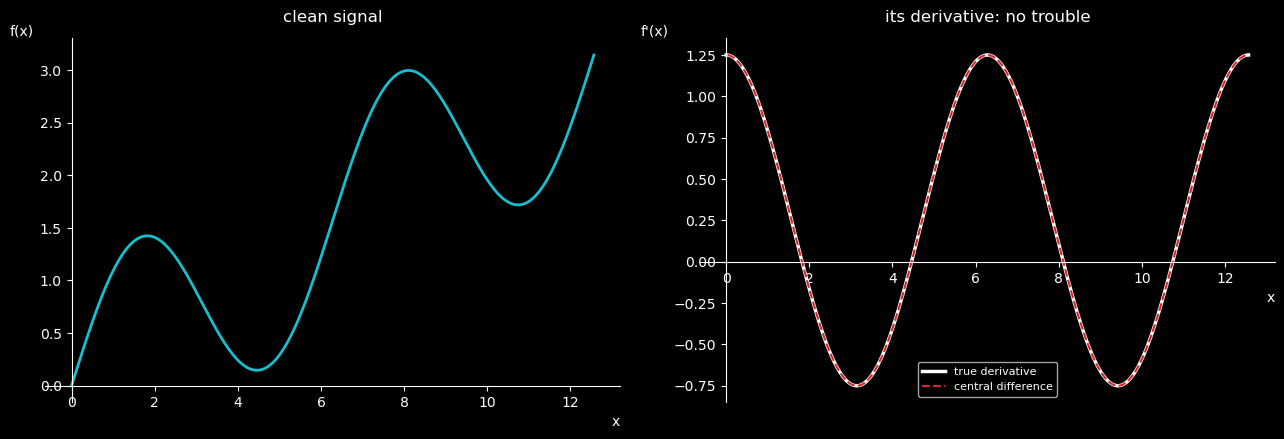

In [2]:
def f_clean(x):
    return np.sin(x) + 0.25 * x

def df_true(x):
    return np.cos(x) + 0.25

n = 400
x = np.linspace(0, 4*np.pi, n)
dx = x[1] - x[0]
y_clean = f_clean(x)

def central_diff(y, step):
    # returns the derivative at the INTERIOR points only
    return (y[2:] - y[:-2]) / (2*step)

d_clean = central_diff(y_clean, dx)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(x, y_clean, color="tab:cyan", lw=2)
axes[0].set_title("clean signal", pad=12)
axes[0].set_ylabel("f(x)", loc="top", rotation=0)

axes[1].plot(x, df_true(x), color="white", lw=2.5, label="true derivative")
axes[1].plot(x[1:-1], d_clean, "--", color="tab:red", lw=1.5, label="central difference")
axes[1].set_title("its derivative: no trouble", pad=12)
axes[1].set_ylabel("f'(x)", loc="top", rotation=0)
axes[1].legend(fontsize=8)

for ax in axes:
    center_axes(ax); ax.set_xlabel("x", loc="right")
plt.tight_layout()
plt.show()

## 2. Add a little noise — and watch it explode

Now add random noise with a standard deviation of just **0.05**. On the signal itself that is barely
visible: the curve looks slightly fuzzy, nothing more.

Differentiate it, though, and the result is unrecognizable. Note the vertical scale on the right-hand
plot: the noise in the derivative is **far** larger than the noise in the signal — the printout
below measures how much — and it completely swamps the true answer.

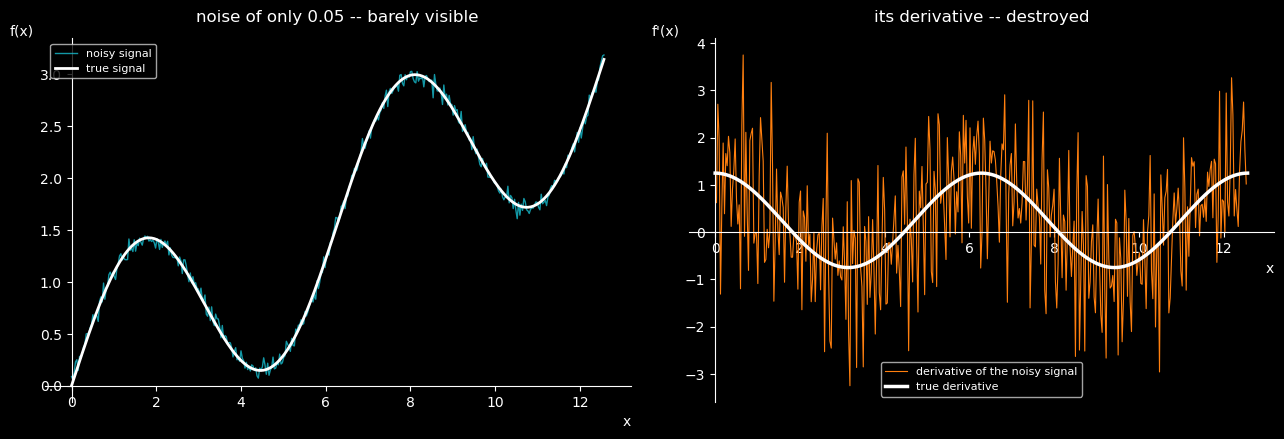

noise added to the signal          : 0.049
noise left in the derivative       : 1.064   <- 22x larger
spread of the true derivative      : 0.708
spread of the noisy derivative     : 1.276   <- overwhelmed

predicted amplification, roughly eps/h = 1.6


In [3]:
noise_level = 0.05
y_noisy = y_clean + np.random.normal(0, noise_level, n)

d_noisy = central_diff(y_noisy, dx)

# measure the amplification rather than quoting it (reported below the plot)
noise_in_signal = np.std(y_noisy - y_clean)
noise_in_derivative = np.std(d_noisy - df_true(x[1:-1]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(x, y_noisy, color="tab:cyan", lw=1, alpha=0.8, label="noisy signal")
axes[0].plot(x, y_clean, color="white", lw=2, label="true signal")
axes[0].set_title(f"noise of only {noise_level} -- barely visible", pad=12)
axes[0].set_ylabel("f(x)", loc="top", rotation=0)
axes[0].legend(fontsize=8)

axes[1].plot(x[1:-1], d_noisy, color="tab:orange", lw=0.8, label="derivative of the noisy signal")
axes[1].plot(x, df_true(x), color="white", lw=2.5, label="true derivative")
axes[1].set_title("its derivative -- destroyed", pad=12)
axes[1].set_ylabel("f'(x)", loc="top", rotation=0)
axes[1].legend(fontsize=8)

for ax in axes:
    center_axes(ax); ax.set_xlabel("x", loc="right")
plt.tight_layout()
plt.show()

print(f"noise added to the signal          : {noise_in_signal:.3f}")
print(f"noise left in the derivative       : {noise_in_derivative:.3f}"
      f"   <- {noise_in_derivative / noise_in_signal:.0f}x larger")
print(f"spread of the true derivative      : {df_true(x).std():.3f}")
print(f"spread of the noisy derivative     : {d_noisy.std():.3f}   <- overwhelmed")
print(f"\npredicted amplification, roughly eps/h = {noise_level/dx:.1f}")

The predicted amplification $\epsilon/h$ lands in the right ballpark — it is a rough scale estimate,
not an exact formula. And notice the trap: the denser your
sampling, the *smaller* $h$ is, and the *worse* this gets. Higher-resolution data makes naive
differentiation harder, not easier.

## 3. Smooth first, then differentiate

The fix is to average away the randomness before differentiating. A **rolling average** slides a
window of width $w$ along the signal and replaces each point with the mean inside that window. Random
errors partially cancel; the underlying trend survives.

`pandas` has this built in as `.rolling(w, center=True).mean()`.

window = 21 points -> 20 points lost at the ends (5% of the signal)


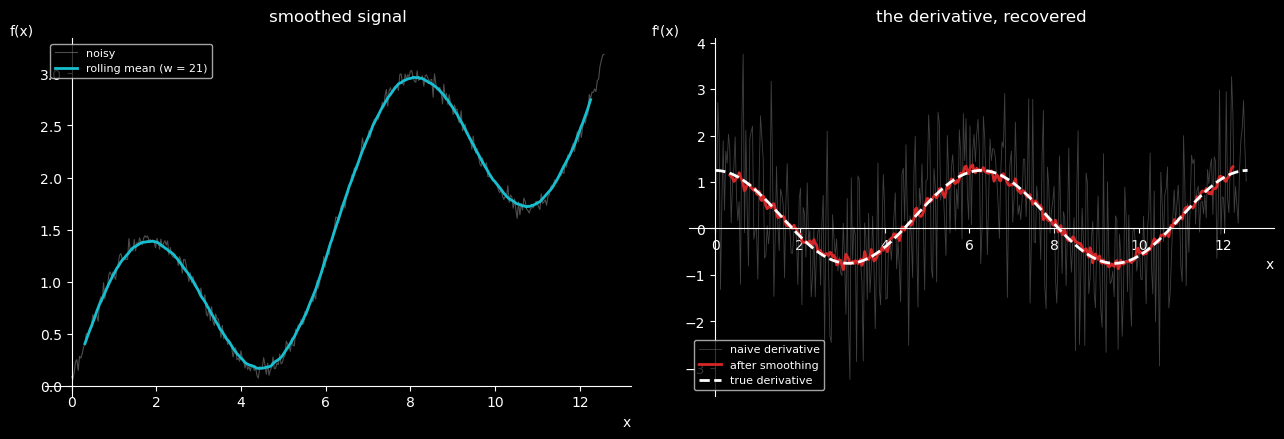

In [4]:
window = 21
series = pd.Series(y_noisy)
y_smooth = series.rolling(window, center=True).mean().to_numpy()

# the rolling average leaves NaN at the ends, where the window hangs off the data
valid = ~np.isnan(y_smooth)
print(f"window = {window} points -> {np.sum(~valid)} points lost at the ends "
      f"({np.sum(~valid)/n*100:.0f}% of the signal)")

xs_v = x[valid]
d_smooth = central_diff(y_smooth[valid], dx)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(x, y_noisy, color="gray", lw=0.8, alpha=0.6, label="noisy")
axes[0].plot(xs_v, y_smooth[valid], color="tab:cyan", lw=2, label=f"rolling mean (w = {window})")
axes[0].set_title("smoothed signal", pad=12)
axes[0].set_ylabel("f(x)", loc="top", rotation=0)
axes[0].legend(fontsize=8)

axes[1].plot(x[1:-1], d_noisy, color="gray", lw=0.6, alpha=0.5, label="naive derivative")
axes[1].plot(xs_v[1:-1], d_smooth, color="tab:red", lw=2, label="after smoothing")
axes[1].plot(x, df_true(x), color="white", lw=2, ls="--", label="true derivative")
axes[1].set_title("the derivative, recovered", pad=12)
axes[1].set_ylabel("f'(x)", loc="top", rotation=0)
axes[1].legend(fontsize=8)

for ax in axes:
    center_axes(ax); ax.set_xlabel("x", loc="right")
plt.tight_layout()
plt.show()

The true derivative is back. Two things to notice about the cost: the smoothed curve is a little
**flatter** than the truth at the peaks, and the signal is **shorter** — the window can't be centred
on points near the ends, so those are lost.

## 4. Choosing the window

The window width is a genuine trade-off, and neither extreme is right:

- **Too narrow** — barely any averaging, the noise survives.
- **Too wide** — the noise is gone, but real peaks get flattened and the answer is systematically wrong.

Below, four widths, with the error against the known truth measured for each.

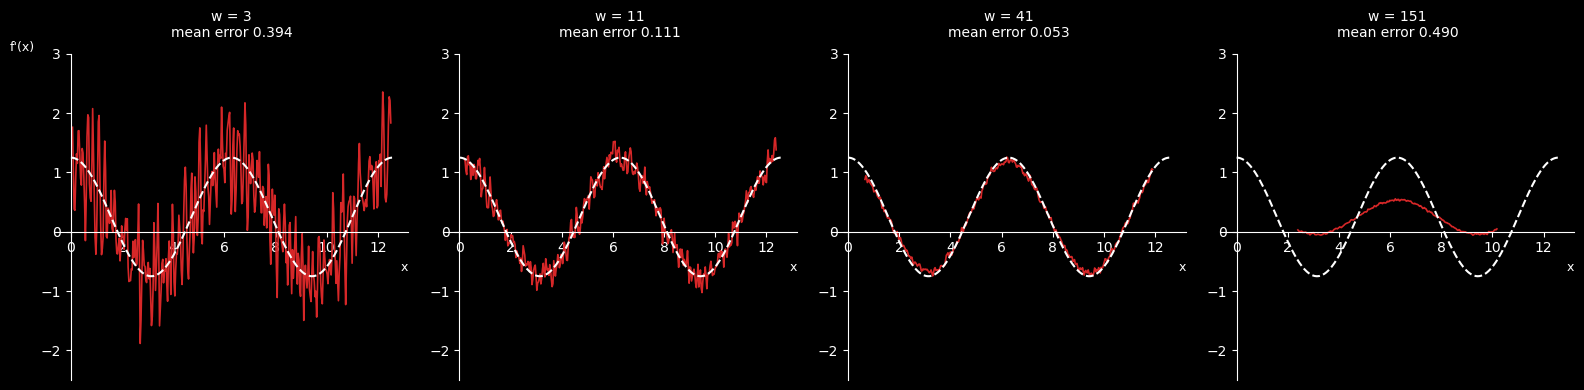

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, w in zip(axes, [3, 11, 41, 151]):
    ys = pd.Series(y_noisy).rolling(w, center=True).mean().to_numpy()
    v = ~np.isnan(ys)
    d = central_diff(ys[v], dx)
    xv = x[v][1:-1]
    ax.plot(xv, d, color="tab:red", lw=1.2)
    ax.plot(x, df_true(x), color="white", lw=1.5, ls="--")
    center_axes(ax); ax.set_xlabel("x", loc="right", fontsize=9)
    ax.set_ylim(-2.5, 3)
    err = np.mean(np.abs(d - df_true(xv)))
    ax.set_title(f"w = {w}\nmean error {err:.3f}", pad=12, fontsize=10)
axes[0].set_ylabel("f'(x)", loc="top", rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

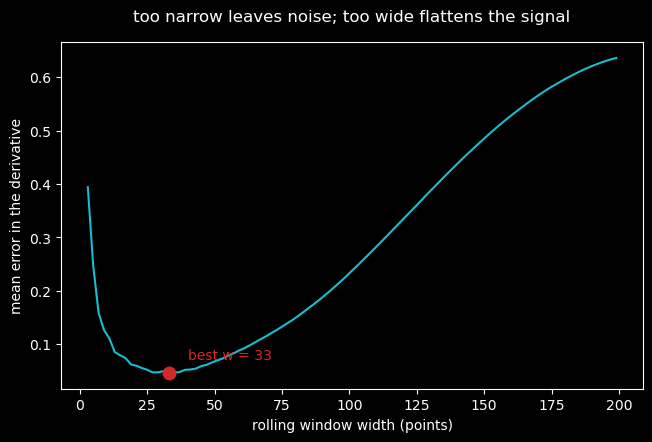

best window: 33 points, mean error 0.0461
compare: no smoothing at all gives 0.8603


In [6]:
# sweep the window width and find where the total error bottoms out
widths = np.arange(3, 200, 2)
errs = []
for w in widths:
    ys = pd.Series(y_noisy).rolling(w, center=True).mean().to_numpy()
    v = ~np.isnan(ys)
    d = central_diff(ys[v], dx)
    errs.append(np.mean(np.abs(d - df_true(x[v][1:-1]))))
errs = np.array(errs)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(widths, errs, color="tab:cyan")
best = widths[np.argmin(errs)]
ax.plot(best, errs.min(), "o", color="tab:red", markersize=9)
ax.annotate(f"best w = {best}", (best, errs.min()), textcoords="offset points",
            xytext=(14, 10), color="tab:red")
ax.set_xlabel("rolling window width (points)")
ax.set_ylabel("mean error in the derivative")
ax.set_title("too narrow leaves noise; too wide flattens the signal", pad=15)
plt.show()

print(f"best window: {best} points, mean error {errs.min():.4f}")
print(f"compare: no smoothing at all gives {np.mean(np.abs(d_noisy - df_true(x[1:-1]))):.4f}")

The same U-shaped curve as §3.4-1's error-versus-$h$ plot, for a different reason — and the same
lesson. There is an optimum in the middle, and both extremes are bad. Numerical methods are full of
these.

## 5. Summary

- Differentiation **amplifies noise** by roughly $\epsilon/h$ — and smaller $h$ makes it worse, so
  denser data does not rescue you.
- Noise that is invisible in the signal can completely destroy its derivative.
- **Smooth before differentiating.** A rolling average (`.rolling(w, center=True).mean()`) averages
  random error down while preserving the trend.
- The window width is a trade-off: too narrow leaves noise, too wide flattens real features. Sweep it
  and pick the middle.
- Smoothing also **costs data** at both ends, where the window can't be centred.

Next: all of this applied to a genuinely messy real series — 14 years of hourly electricity demand
(`U3-4_NumericalDerivatives-3_RealData`).